<a href="https://colab.research.google.com/github/Mumthaz-Alfan/ICT-ACTIVITY/blob/main/casestudyunsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering



In [39]:
df = pd.read_csv('/content/adult_dataset.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [40]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [41]:
df.shape

(48842, 15)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [43]:
print('Duplicated rows :' ,df.duplicated().sum())

Duplicated rows : 16


In [44]:
df[df.duplicated()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5104,90.0,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35.0,United-States,<=50K
9171,21.0,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10.0,United-States,<=50K
11631,20.0,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10.0,United-States,<=50K
17040,46.0,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,<=50K
18698,19.0,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
22300,25.0,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40.0,Guatemala,<=50K
22367,44.0,Private,367749,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,45.0,Mexico,<=50K
25872,23.0,Private,240137,5th-6th,3,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,55.0,Mexico,<=50K
28230,27.0,Private,255582,HS-grad,9,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,40.0,United-States,<=50K
31993,19.0,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14.0,United-States,<=50K


In [45]:
# Show all instances (original + duplicates) sorted together
df[df.duplicated(keep=False)].sort_values(by=['fnlwgt', 'age'])

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
41810,29.0,Private,36440,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40.0,United-States,<=50K.
43773,29.0,Private,36440,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40.0,United-States,<=50K.
2303,90.0,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35.0,United-States,<=50K
5104,90.0,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35.0,United-States,<=50K
33880,37.0,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40.0,United-States,<=50K.
43750,37.0,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40.0,United-States,<=50K.
17673,19.0,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
18698,19.0,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
5805,20.0,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10.0,United-States,<=50K
11631,20.0,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10.0,United-States,<=50K


In [46]:
# Drop duplicates and save to a new variable (or overwrite df)
df_clean = df.drop_duplicates()

In [47]:
df_clean

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [48]:
print('Duplicated columns :' ,df.T.duplicated().sum())

Duplicated columns : 0


In [49]:
df_clean.shape

(48826, 15)

In [50]:
# 1. Start with a clean copy to prevent SettingWithCopyWarning
df_clean = df.drop_duplicates().copy()

# 2. Replace '?' string values with standard np.nan
df_clean.replace('?', np.nan, inplace=True)

# 3. Handle extreme outliers on df_clean FIRST
df_clean.loc[df_clean['age'] > 100, 'age'] = np.nan
df_clean.loc[df_clean['hours-per-week'] > 168, 'hours-per-week'] = np.nan

# 4. Impute numerical columns with median
for col in ['age', 'hours-per-week']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 5. Impute categorical columns with mode
for col in ['workclass', 'occupation', 'native-country']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 6. Check total missing values in df_clean
print("Remaining NaNs in df_clean:", df_clean.isnull().sum().sum())

Remaining NaNs in df_clean: 0


In [51]:
# Separate income before clustering
y_income = df_clean['income']

# Drop income from the feature set used for clustering
X = df_clean.drop(columns=['income'])

In [52]:
# Check total count of '?' values across all columns
(df_clean == '?').sum().sum()

np.int64(0)

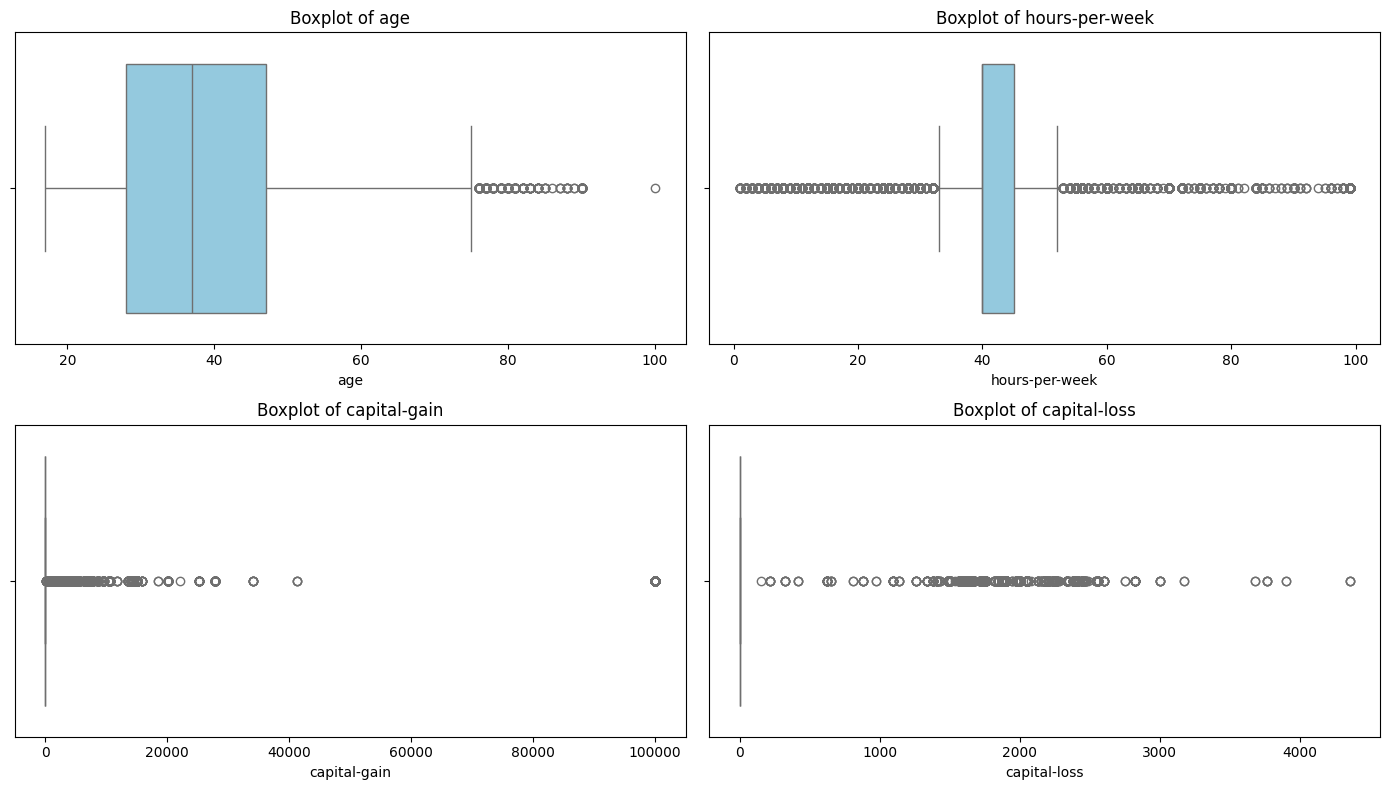

In [53]:


# Numerical features to check for outliers
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

# Plot boxplots for numerical columns
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_clean[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

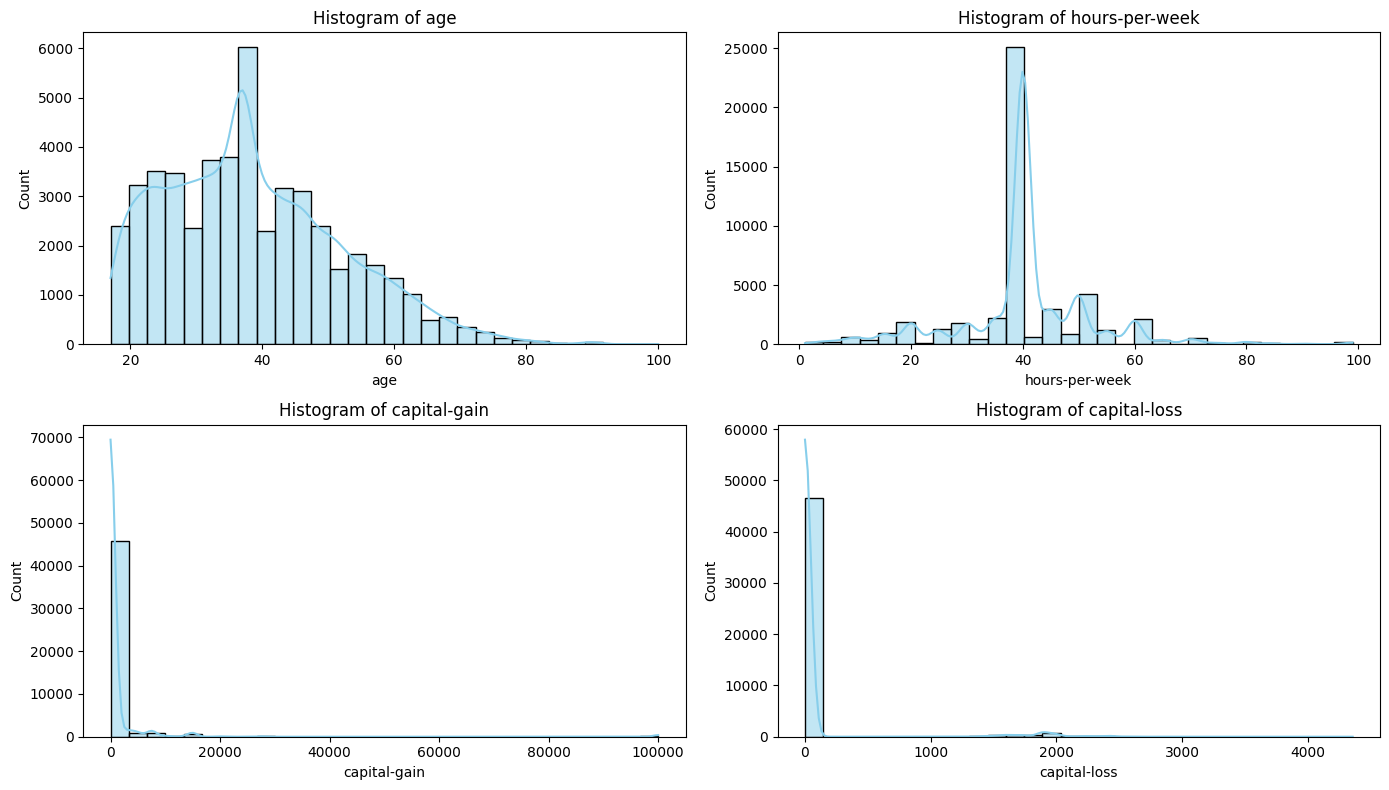

In [54]:


# Numerical features to check distributions
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

# Plot histograms with KDE curves
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col}', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [55]:


# 1. Select numerical features to treat
num_cols = ['age', 'hours-per-week']

# 2. Detect & Treat using IQR Capping (Winsorization)
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside bounds
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

# Verify updated statistics
df_clean[num_cols].describe()

,age,hours-per-week
count,48826.000000,48826.000000
mean,38.526830,41.127954
std,13.260587,6.031468
min,17.000000,32.500000
25%,28.000000,40.000000
50%,37.000000,40.000000
75%,47.000000,45.000000
max,75.500000,52.500000


In [56]:
# Apply Upper-Bound IQR Capping for capital-gain and capital-loss
for col in ['capital-gain', 'capital-loss']:
    # Cap at upper 99th percentile limit
    upper_limit = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=upper_limit)

# Verify updated statistics
df_clean[['capital-gain', 'capital-loss']].describe()

,capital-gain,capital-loss
count,48826.000000,48826.000000
mean,625.972392,84.308934
std,2502.328713,384.707189
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,15024.000000,2001.000000


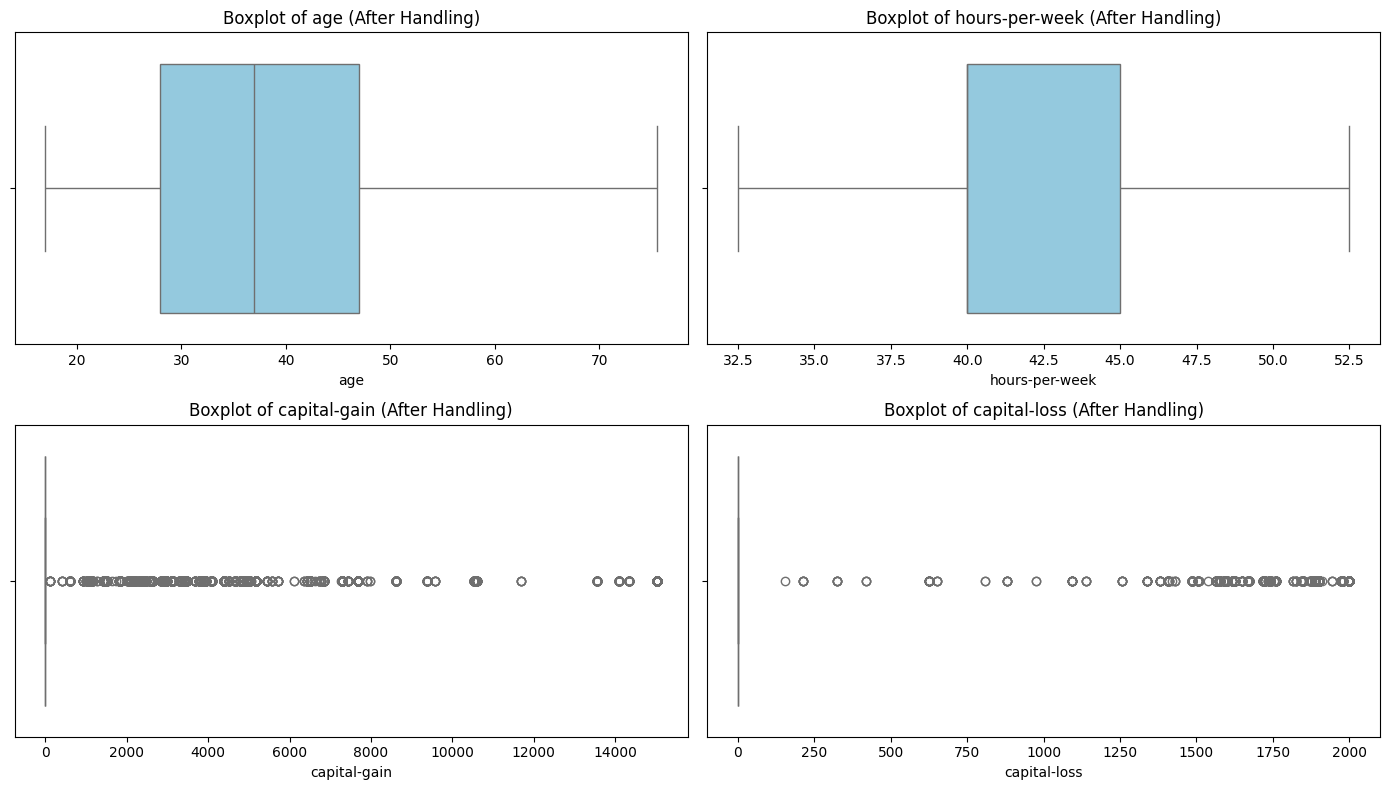

In [57]:


# Select all 4 numerical columns
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

# Create a 2x2 grid of box plots
plt.figure(figsize=(14, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_clean[col] , color='skyblue')
    plt.title(f'Boxplot of {col} (After Handling)', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [58]:
# Select all object (categorical) columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

# Print value counts for each categorical feature
for col in cat_cols:
    print(f"=== Value Counts for '{col}' ===")
    print(df_clean[col].value_counts())
    print("\n" + "-"*40 + "\n")

=== Value Counts for 'workclass' ===
workclass
Private             37330
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64

----------------------------------------

=== Value Counts for 'education' ===
education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64

----------------------------------------

=== Value Counts for 'marital-status' ===
marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1

In [59]:


# 1. Ordinal Encoding for 'education' (preserving order)
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th',
    '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc',
    'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'
]
edu_map = {val: i for i, val in enumerate(education_order)}
df_clean['education_encoded'] = df_clean['education'].map(edu_map)

# Drop original 'education' or 'education-num' to avoid redundant columns
df_clean.drop(columns=['education', 'education-num', 'fnlwgt'], inplace=True, errors='ignore')

# 2. Binary Encoding for 2-category features
le = LabelEncoder()
df_clean['sex'] = le.fit_transform(df_clean['sex'])

# Strip trailing dots from income values if present (e.g., '<=50K.') before encoding
df_clean['income'] = df_clean['income'].str.rstrip('.')
df_clean['income'] = le.fit_transform(df_clean['income'])

# 3. One-Hot Encoding for remaining nominal categories
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

# Convert all True/False boolean columns to integers (1/0)
df_encoded = df_encoded.astype(int)

# Check updated shape and preview
print("Encoded Dataset Shape:", df_encoded.shape)
df_encoded.head()

Encoded Dataset Shape: (48826, 82)


,age,sex,capital-gain,capital-loss,hours-per-week,income,education_encoded,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,1,2174,0,40,0,12,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,1,0,0,32,0,12,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,1,0,0,40,0,8,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53,1,0,0,40,0,6,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,0,0,0,40,0,12,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [60]:


# 1. Define the numerical columns to scale
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

# 2. Initialize StandardScaler
scaler = StandardScaler()

# 3. Fit and transform numerical columns in your dataframe
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Preview scaled data
df_encoded.head()

,age,sex,capital-gain,capital-loss,hours-per-week,income,education_encoded,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.035983,1,0.618641,-0.219153,-0.164594,0,12,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.866147,1,-0.250159,-0.219153,-1.485780,0,12,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.039486,1,-0.250159,-0.219153,-0.164594,0,8,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,1.092555,1,-0.250159,-0.219153,-0.164594,0,6,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,-0.794180,0,-0.250159,-0.219153,-0.164594,0,12,0,0,1,...,0,0,0,0,0,0,0,0,0,0


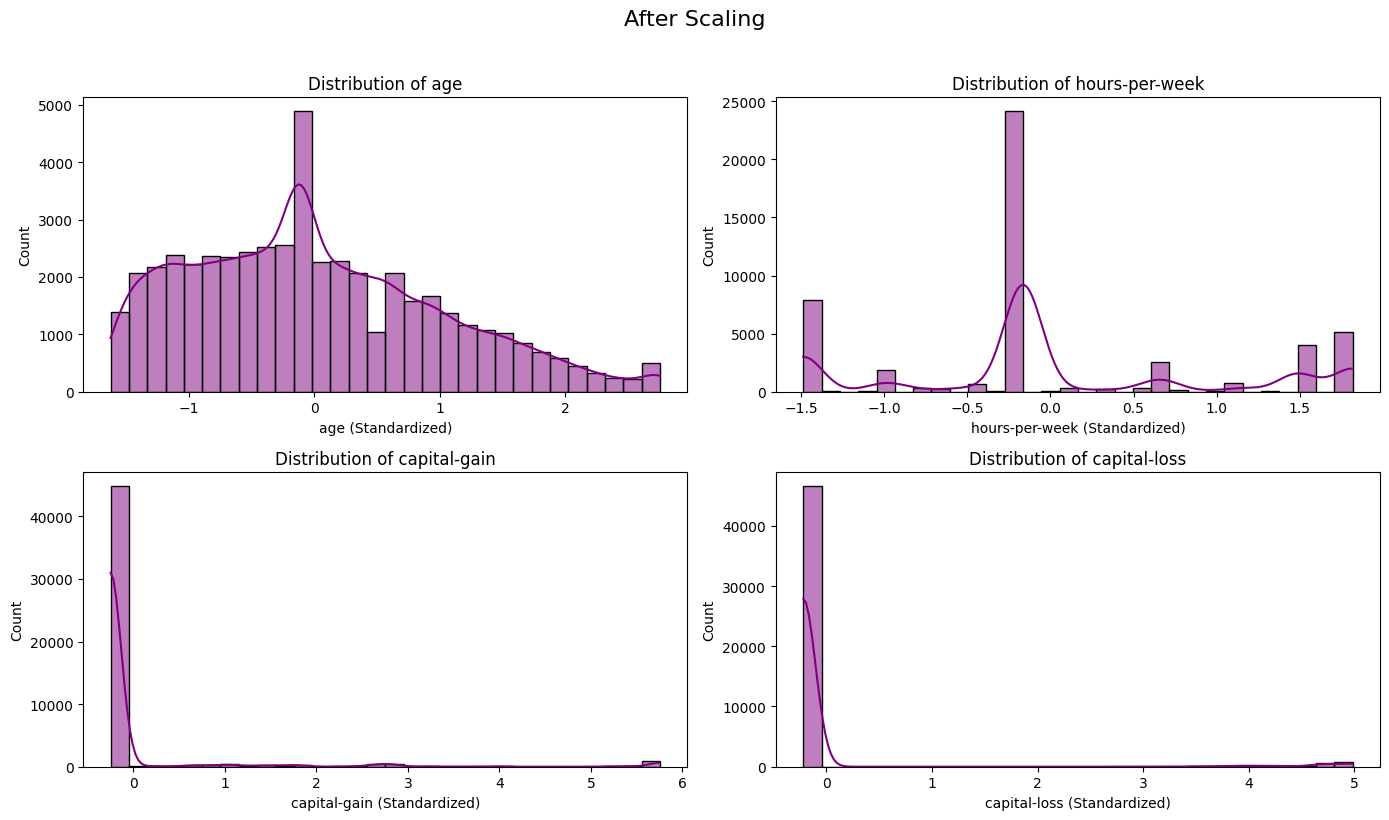

In [61]:


num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_encoded[col], kde=True, bins=30, color='purple')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(f'{col} (Standardized)')
plt.suptitle('After Scaling', fontsize = 16,y=1.02)
plt.tight_layout()
plt.show()

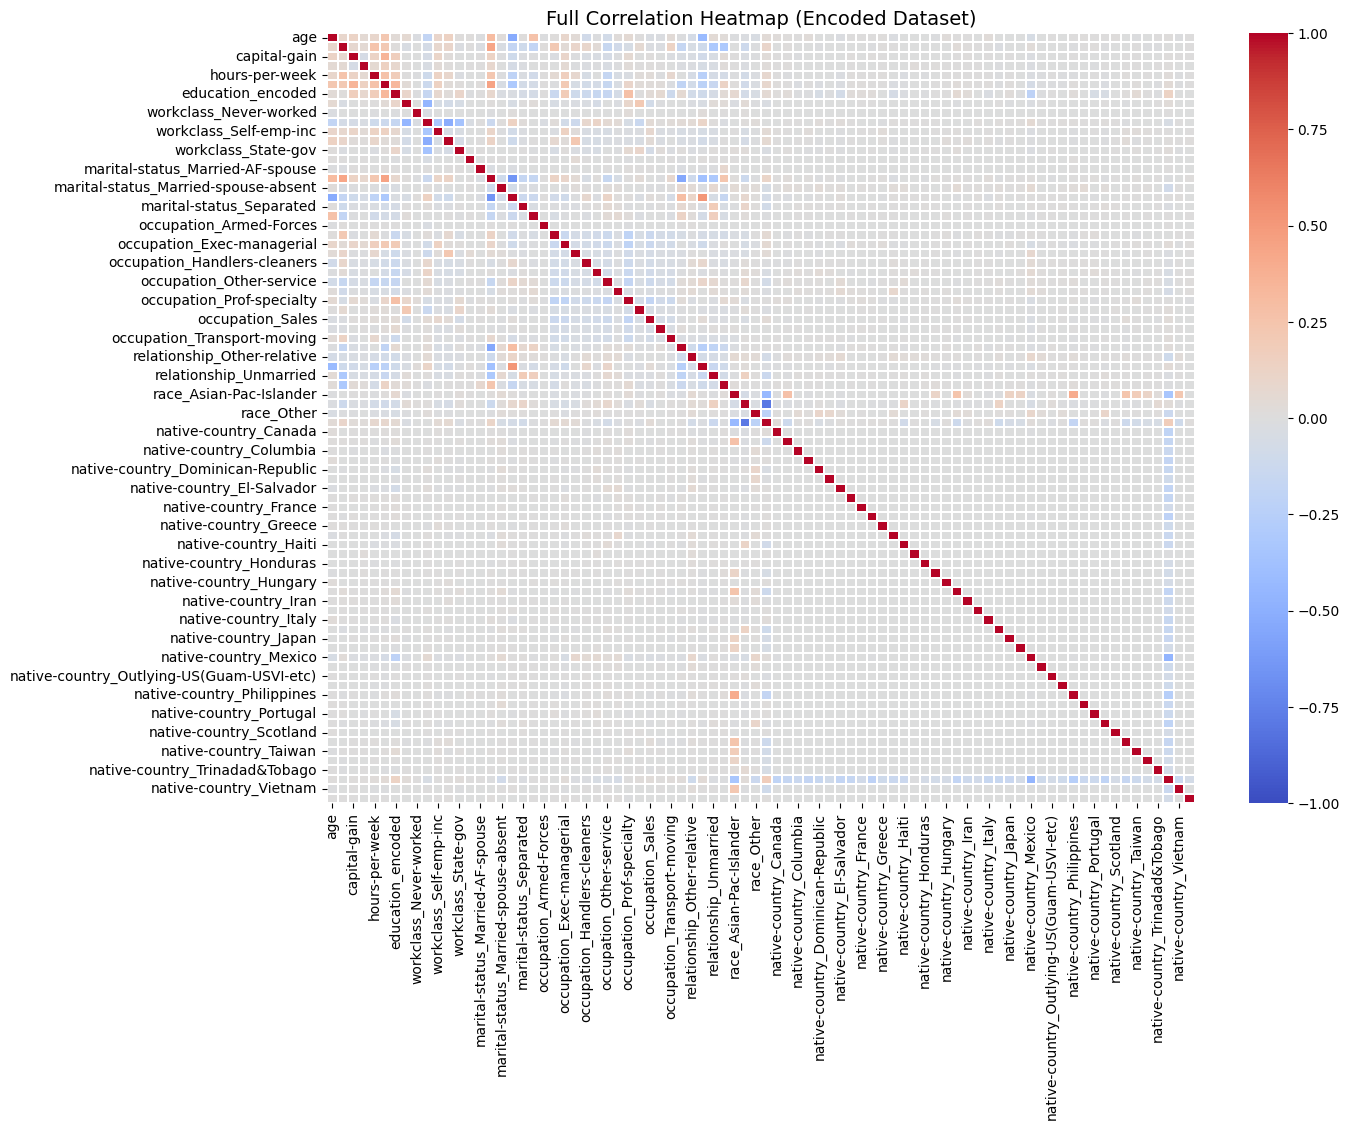

In [62]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.1)
plt.title('Full Correlation Heatmap (Encoded Dataset)', fontsize=14)
plt.show()

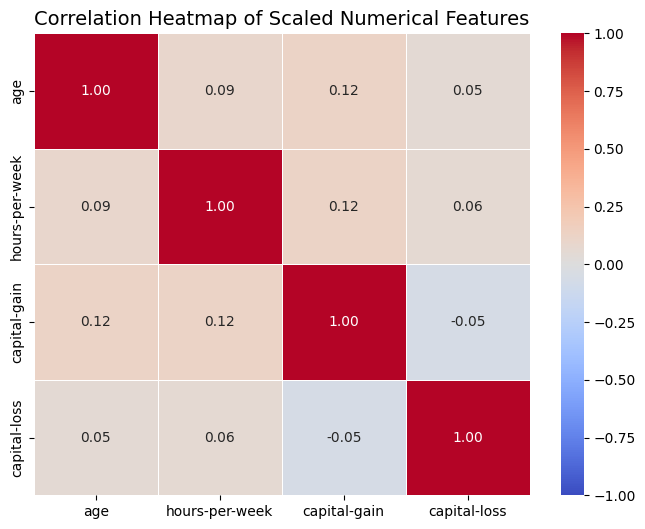

In [63]:


# Numerical columns after scaling
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

# Calculate correlation matrix on scaled df_encoded
corr_scaled = df_encoded[num_cols].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_scaled, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Scaled Numerical Features', fontsize=14)
plt.show()

In [64]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss', 'education-num', 'fnlwgt']

# 2. One-Hot Encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 3. Scale all numerical columns
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print("Preprocessing Complete!")
print("Final Matrix Shape:", X_encoded.shape)
print("Remaining NaNs:", X_encoded.isnull().sum().sum())

Preprocessing Complete!
Final Matrix Shape: (48826, 97)
Remaining NaNs: 0


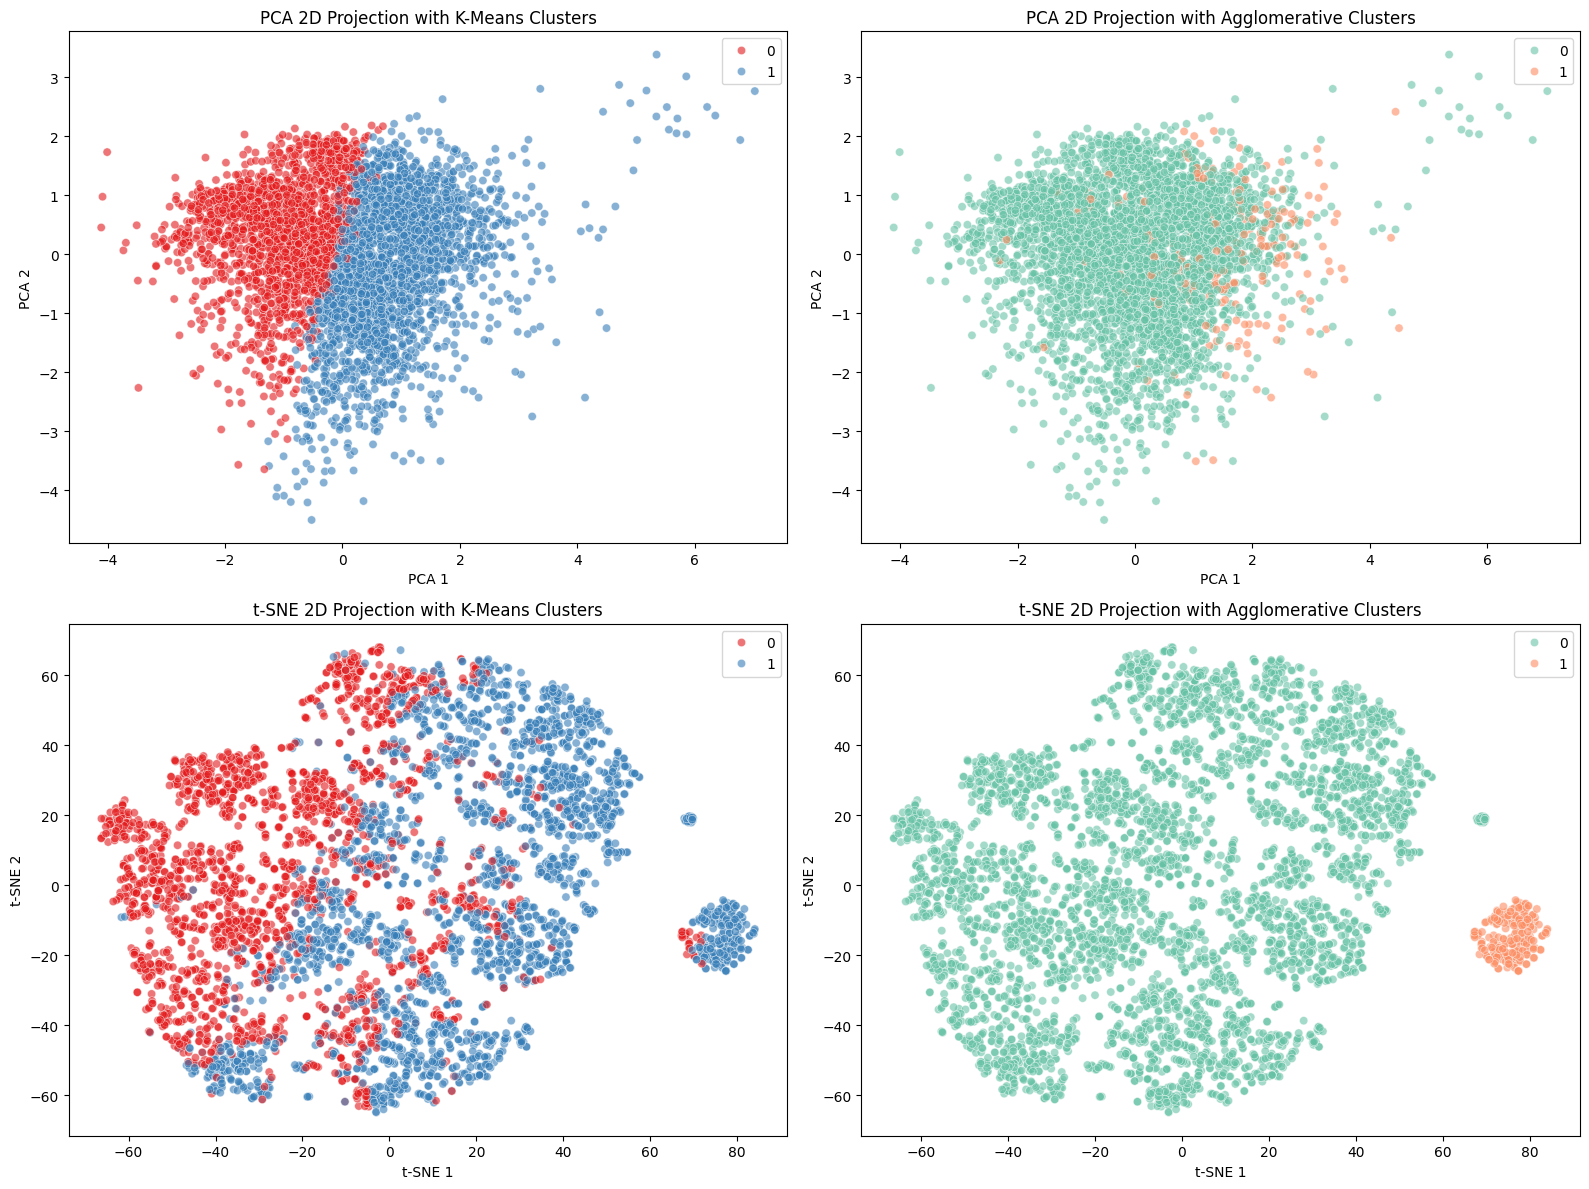

In [65]:



X_sample = X_encoded.sample(n=5000, random_state=42)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# t-SNE (Non-linear reduction - preserves local neighbor clusters)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)


# Fit K-Means (k=2)
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_sample)

# Fit Agglomerative Clustering (k=2)
agg = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
agg_labels = agg.fit_predict(X_sample)

#  COLOR-CODED VISUALIZATIONS (2x2 Grid)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA + K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='Set1', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('PCA 2D Projection with K-Means Clusters', fontsize=12)
axes[0, 0].set_xlabel('PCA 1')
axes[0, 0].set_ylabel('PCA 2')

# Subplot 2: PCA + Agglomerative
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels, palette='Set2', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('PCA 2D Projection with Agglomerative Clusters', fontsize=12)
axes[0, 1].set_xlabel('PCA 1')
axes[0, 1].set_ylabel('PCA 2')

# Subplot 3: t-SNE + K-Means
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette='Set1', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('t-SNE 2D Projection with K-Means Clusters', fontsize=12)
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')

# Subplot 4: t-SNE + Agglomerative
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=agg_labels, palette='Set2', alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('t-SNE 2D Projection with Agglomerative Clusters', fontsize=12)
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 1. FIT K-MEANS ON FULL PREPROCESSED DATASET
# ---------------------------------------------------------
X_clustering = X_encoded.drop(columns=['Cluster'], errors='ignore')

# Fit K-Means with k=2
kmeans_full = KMeans(n_clusters=2, init='k-means++', random_state=42)
full_cluster_labels = kmeans_full.fit_predict(X_clustering)

# Attach cluster labels back to original df_clean
df_profile = df_clean.copy()
df_profile['Cluster'] = full_cluster_labels

# ---------------------------------------------------------
# 2. NUMERICAL PROFILING (Automatically select available columns)
# ---------------------------------------------------------
print("=" * 65)
print("  1. NUMERICAL ATTRIBUTE MEANS PER CLUSTER")
print("=" * 65)

# Dynamically find existing numerical columns in df_profile
possible_num = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
num_cols = [col for col in possible_num if col in df_profile.columns]

print(df_profile.groupby('Cluster')[num_cols].mean())

# ---------------------------------------------------------
# 3. CATEGORICAL PROFILING
# ---------------------------------------------------------
print("\n" + "=" * 65)
print("  2. MOST COMMON CATEGORICAL TRAITS PER CLUSTER (%)")
print("=" * 65)

possible_cat = ['education', 'marital-status', 'occupation', 'sex', 'workclass']
cat_cols = [col for col in possible_cat if col in df_profile.columns]

for col in cat_cols:
    print(f"\n>>> Top 3 Traits for '{col.upper()}' <<<")

    print("  Cluster 0 (Entry-Level / Lower-Income Profile):")
    c0 = df_profile[df_profile['Cluster'] == 0][col].value_counts(normalize=True).head(3) * 100
    for trait, pct in c0.items():
        print(f"    - {trait}: {pct:.2f}%")

    print("  Cluster 1 (Established / High-Earning Profile):")
    c1 = df_profile[df_profile['Cluster'] == 1][col].value_counts(normalize=True).head(3) * 100
    for trait, pct in c1.items():
        print(f"    - {trait}: {pct:.2f}%")

# ---------------------------------------------------------
# 4. GROUND TRUTH VALIDATION (Cluster vs. Income)
# ---------------------------------------------------------
if 'income' in df_profile.columns:
    print("\n" + "=" * 65)
    print("  3. CROSS-TABULATION: CLUSTER VS. ACTUAL INCOME COLUMN (%)")
    print("=" * 65)
    print(pd.crosstab(df_profile['Cluster'], df_profile['income'], normalize='index') * 100)

  1. NUMERICAL ATTRIBUTE MEANS PER CLUSTER
               age  hours-per-week  capital-gain  capital-loss
Cluster                                                       
0        41.799735       43.781546   1319.809372    222.357405
1        36.840456       39.760683    268.470751     13.179034

  2. MOST COMMON CATEGORICAL TRAITS PER CLUSTER (%)

>>> Top 3 Traits for 'MARITAL-STATUS' <<<
  Cluster 0 (Entry-Level / Lower-Income Profile):
    - Married-civ-spouse: 59.06%
    - Never-married: 23.86%
    - Divorced: 12.00%
  Cluster 1 (Established / High-Earning Profile):
    - Married-civ-spouse: 39.01%
    - Never-married: 37.68%
    - Divorced: 14.39%

>>> Top 3 Traits for 'OCCUPATION' <<<
  Cluster 0 (Entry-Level / Lower-Income Profile):
    - Prof-specialty: 37.10%
    - Exec-managerial: 22.03%
    - Sales: 11.93%
  Cluster 1 (Established / High-Earning Profile):
    - Craft-repair: 14.93%
    - Prof-specialty: 14.91%
    - Other-service: 13.05%

>>> Top 3 Traits for 'SEX' <<<
  Clust

In [71]:


# ---------------------------------------------------------
# POLICY RECOMMENDATIONS MAPPING BASED ON CLUSTER PROFILES
# ---------------------------------------------------------

policy_recommendations = [
    {
        "Policy Program": "Upskilling Programs",
        "Target Group": "Cluster 0",
        "Rationale": "Lower average education levels and entry-level positions. Technical & vocational training offers the highest career mobility."
    },
    {
        "Policy Program": "Tax Reforms (Progressive & Capital Gains)",
        "Target Group": "Cluster 1",
        "Rationale": "Higher earning power and larger capital asset holdings. Progressive brackets & capital gains regulations directly apply here."
    },
    {
        "Policy Program": "Financial Aid & Subsidies",
        "Target Group": "Cluster 0",
        "Rationale": "Dominates the lower-income bracket (<=50K). Direct support (childcare, housing, EITC) relieves immediate financial strain."
    },
    {
        "Policy Program": "Diversity & Inclusion (D&I)",
        "Target Group": "Cluster 0 (Transition to Cluster 1)",
        "Rationale": "Higher proportion of entry-level and underrepresented groups. Inclusion & pay-equity initiatives help overcome growth barriers."
    }
]

# Convert to DataFrame for a clean table output in Colab
df_policy = pd.DataFrame(policy_recommendations)

# Display formatted summary
print("=" * 70)
print("       POLICY RECOMMENDATIONS BY CLUSTER PROFILE")
print("=" * 70)
display(df_policy)

       POLICY RECOMMENDATIONS BY CLUSTER PROFILE


,Policy Program,Target Group,Rationale
0,Upskilling Programs,Cluster 0,Lower average education levels and entry-level...
1,Tax Reforms (Progressive & Capital Gains),Cluster 1,Higher earning power and larger capital asset ...
2,Financial Aid & Subsidies,Cluster 0,Dominates the lower-income bracket (<=50K). Di...
3,Diversity & Inclusion (D&I),Cluster 0 (Transition to Cluster 1),Higher proportion of entry-level and underrepr...
